# `Homo_gridblock_Iceland.m` — Python/Jupyter port
Numerically matched port using the shared `gridblock_jupyter.py` implementation. MATLAB's geographic pair definitions, rotated-grid interpolation, accumulators, homogeneity definition, optional bootstrap, and MAT field names are retained.

In [45]:
from pathlib import Path
import numpy as np

from gridblock_jupyter_iceland_pdf import run_iceland
import sys
import importlib

sys.path.insert(
    0,
    "/meddy/simingzhang/Analysis/python/python3",
)

import gridblock_jupyter_iceland_pdf as gb_iceland

gb_iceland = importlib.reload(
    gb_iceland
)

# ============================================================
# 1. 基本设置
# ============================================================

ini = "_rough"

# case="wave",
# nparticles=289

data_root = Path(
    "/meddy/simingzhang/Data/Parcels_data"
)

subdirs = {
    "_grid": "tranV_onetime_spectukey",
    "_rough": "tranV_onetime_roughdistr_tukey",
    "_rough_1mon": "tranV_onetime_roughdistr_tukey",
    "_rough_2mon": "tranV_onetime_roughdistr_tukey",

    "_roughsmall": "tranV_onetime_roughsmallregion",
    "_roughsmall_1mon": "tranV_onetime_roughsmallregion",
    "_roughsmall_2mon": "tranV_onetime_roughsmallregion",
    "_roughsmall_3mon": "tranV_onetime_roughsmallregion",

    "_roughLASER": "tranV_onetime_roughLASER",
    "_roughsmall_rot": "tranV_onetime_roughsmallregion_rot",
    "_roughsmall_div": "tranV_onetime_roughsmallregion_div",

    "_cruise": "tranV_cruise_roughsmallregion",

    "_roughsmall_500m": "tranV_onetime_roughsmallregion_500m",
    "_rough_500m": "tranV_onetime_rough_500m",

    "_roughbox200g_500m": "tranV_onetime_roughbox200g_500m",
    "_roughbox100g_500m": "tranV_onetime_roughbox100g_500m",
}


# ============================================================
# 2. Eulerian reference scales
#    单位：km
# ============================================================

# r_requested_km = np.array(
#     [
#         2.00000000,
#         2.60352118,
#         3.38916126,
#         4.41187656,
#         5.74320702,
#         7.47628055,
#         9.73232737,
#         12.66916020,
#         16.49221344,
#         21.46891348,
#         27.94738544,
#         36.38080492,
#         47.35909802,
#         61.65020731,
#         80.25381015,
#         104.47124713,
#         135.99655214,
#         177.03495174,
#         230.45712296,
#         300.00000000,
#     ],
#     dtype=float,
# )

r_requested_km = np.geomspace(4.0, 300, 12)


r_requested_km = np.sort(
    np.unique(
        r_requested_km[
            np.isfinite(r_requested_km)
            & (r_requested_km > 0)
        ]
    )
)

print("Eulerian reference scales [km]:")
print(r_requested_km)


# ============================================================
# 3. 输入目录
# ============================================================

if ini not in subdirs:
    raise KeyError(
        f"Unknown ini={ini}. "
        f"Available options are:\n{subdirs.keys()}"
    )

input_dir = data_root / subdirs[ini]

print("\nInitial deployment:", ini)
print("Input directory:", input_dir)


# ============================================================
# 4. N = 289 配置
# ============================================================

cfg_289 = dict(
    case="wave",

    # 只计算 289 粒子
    nparticles=289,

    days=89.5,
    dt=3600.0,

    ini=ini,

    timerange_matlab=np.arange(
        1,
        1941,
    ),

    nblock_I=4,
    nblock_J=4,

    min_pairs=200,
    min_valid_blocks=8,

    # 保留你原来的 bootstrap 设置
    do_bootstrap=True,
    num_boot=1000,
    third_pdf_reservoir_size=100000,

    # None 表示不固定 bootstrap 随机种子
    random_seed=None,

    input_dir=input_dir,

    # 使用 Eulerian 的 20 个尺度，单位 km
    r_requested_km=r_requested_km,

    grid_file=Path(
        "/meddy/simingzhang/Data/RB_iceland_data/"
        "niskin2km_500m_grd.nc"
    ),
)


# ============================================================
# 5. 运行 N = 289
# ============================================================

print("\nStarting Iceland calculation")
print("Case: wave")
print("Initial deployment:", ini)
print("Number of particles:", cfg_289["nparticles"])
print("Number of scales:", len(cfg_289["r_requested_km"]))
print("Scales [km]:", cfg_289["r_requested_km"])

result_289, output_289 = run_iceland(
    cfg_289
)

print("\nCalculation finished.")
print("Output file:")
print(output_289)


# ============================================================
# 6. 检查返回结果
# ============================================================

print("\nReturned result fields:")

if isinstance(result_289, dict):

    for key, value in result_289.items():

        shape = getattr(
            value,
            "shape",
            None,
        )

        print(
            f"{key:40s}",
            type(value).__name__,
            shape,
        )

else:

    print(
        "Warning: result_289 is not a dictionary."
    )

    print(
        "Type:",
        type(result_289),
    )


# ============================================================
# 7. 检查 PDF reservoir
# ============================================================

if isinstance(result_289, dict):

    if "dl_reservoir" in result_289:

        dl_reservoir = np.asarray(
            result_289["dl_reservoir"],
            dtype=float,
        )

        print(
            "\ndl_reservoir shape:",
            dl_reservoir.shape,
        )

        if "dl_reservoir_count" in result_289:

            dl_reservoir_count = np.asarray(
                result_289["dl_reservoir_count"],
                dtype=int,
            ).ravel()

            print(
                "dl_reservoir_count:",
                dl_reservoir_count,
            )

    else:

        print(
            "\nNo dl_reservoir field was returned."
        )

        print(
            "The current run_iceland function may need "
            "to be updated to save PDF samples."
        )

Eulerian reference scales [km]:
[  4.           5.92270506   8.76960881  12.98495162  19.22650967
  28.46823653  42.15224215  62.41382448  92.41466853 136.83620626
 202.61012284 300.        ]

Initial deployment: _rough
Input directory: /meddy/simingzhang/Data/Parcels_data/tranV_onetime_roughdistr_tukey

Starting Iceland calculation
Case: wave
Initial deployment: _rough
Number of particles: 289
Number of scales: 12
Scales [km]: [  4.           5.92270506   8.76960881  12.98495162  19.22650967
  28.46823653  42.15224215  62.41382448  92.41466853 136.83620626
 202.61012284 300.        ]


Iceland Lagrangian pair statistics: 100%|██████████████████| 1939/1939 [02:22<00:00, 13.60time/s]


saved /meddy/simingzhang/Data/Parcels_data/tranV_onetime_roughdistr_tukey/wave_pars_P289T1940_roughgridBlockHL.mat

Calculation finished.
Output file:
/meddy/simingzhang/Data/Parcels_data/tranV_onetime_roughdistr_tukey/wave_pars_P289T1940_roughgridBlockHL.mat

Returned result fields:
Case                                     str None
nparticles                               int None
days                                     float None
dt                                       float None
timerange                                ndarray (1940,)
r_requested_km                           ndarray (12,)
dist_axis                                ndarray (12,)
dist_bin                                 ndarray (13,)
SF1                                      ndarray (12,)
SF2                                      ndarray (12,)
SF2ll                                    ndarray (12,)
SF2tt                                    ndarray (12,)
SF3                                      ndarray (12,)
SF3lll        

# Read

In [59]:
from pathlib import Path
import numpy as np
from scipy.io import loadmat


# ============================================================
# Iceland data directories
# ============================================================

data_root = Path(
    "/meddy/simingzhang/Data/Parcels_data"
)

subdirs = {
    "_grid": "tranV_onetime_spectukey",
    "_rough": "tranV_onetime_roughdistr_tukey",
    "_rough_1mon": "tranV_onetime_roughdistr_tukey",
    "_rough_2mon": "tranV_onetime_roughdistr_tukey",

    "_roughsmall": "tranV_onetime_roughsmallregion",
    "_roughsmall_1mon": "tranV_onetime_roughsmallregion",
    "_roughsmall_2mon": "tranV_onetime_roughsmallregion",
    "_roughsmall_3mon": "tranV_onetime_roughsmallregion",

    "_roughLASER": "tranV_onetime_roughLASER",
    "_roughsmall_rot": "tranV_onetime_roughsmallregion_rot",
    "_roughsmall_div": "tranV_onetime_roughsmallregion_div",

    "_cruise": "tranV_cruise_roughsmallregion",

    "_roughsmall_500m": "tranV_onetime_roughsmallregion_500m",
    "_rough_500m": "tranV_onetime_rough_500m",

    "_roughbox200g_500m": "tranV_onetime_roughbox200g_500m",
    "_roughbox100g_500m": "tranV_onetime_roughbox100g_500m",
}


# ============================================================
# 通用结果读取函数
# ============================================================

def load_iceland_result(
    ini,
    case="wave",
    nparticles=625,
    timerange_matlab=None,
    data_root=data_root,
    subdirs=subdirs,
    filename=None,
):
    """
    读取 Iceland gridblock 结果。

    参数
    ----
    ini : str
        例如 "_rough", "_grid", "_roughsmall"

    case : str
        例如 "wave" 或其他 case 名称

    nparticles : int
        例如 289, 625, 1089

    timerange_matlab : array-like or None
        如果给出，则用最后一个 MATLAB 时间索引构造默认文件名

    filename : str or Path or None
        如果指定，则优先使用这个文件名
    """

    if ini not in subdirs:
        raise KeyError(
            f"Unknown ini={ini}\n"
            f"Available options:\n{list(subdirs.keys())}"
        )

    input_dir = Path(
        data_root
    ) / subdirs[ini]

    if not input_dir.exists():
        raise FileNotFoundError(
            f"Input/result directory does not exist:\n{input_dir}"
        )

    # --------------------------------------------------------
    # 如果用户明确给了文件名
    # --------------------------------------------------------

    if filename is not None:

        result_path = Path(filename)

        if not result_path.is_absolute():
            result_path = input_dir / result_path

    else:

        # ----------------------------------------------------
        # 默认文件名
        #
        # run_iceland() 的保存格式：
        #
        # wave_pars_P289T1940_roughgridBlockHL.mat
        # ----------------------------------------------------

        if timerange_matlab is None:
            timerange_end = 1940
        else:
            timerange_end = int(
                np.max(
                    np.asarray(
                        timerange_matlab,
                        dtype=int,
                    )
                )
            )

        result_path = input_dir / (
            f"{case}_pars_P{nparticles}"
            f"T{timerange_end}"
            f"{ini}gridBlockHL.mat"
        )

    # --------------------------------------------------------
    # 如果默认文件名不存在，则搜索相近文件
    # --------------------------------------------------------

    if not result_path.exists():

        pattern = (
            f"{case}_pars_P{nparticles}"
            f"T*{ini}gridBlockHL.mat"
        )

        candidates = sorted(
            input_dir.glob(pattern)
        )

        if len(candidates) == 0:

            raise FileNotFoundError(
                "Cannot find Iceland result.\n"
                f"Expected:\n{result_path}\n"
                f"Search pattern:\n{input_dir / pattern}"
            )

        if len(candidates) > 1:

            print(
                "Multiple candidate files found:"
            )

            for i, path in enumerate(candidates):
                print(i, path)

            print(
                "\nUsing the last candidate:"
            )

            result_path = candidates[-1]

        else:

            result_path = candidates[0]

    # --------------------------------------------------------
    # 读取 MATLAB 文件
    # --------------------------------------------------------

    try:

        result = loadmat(
            result_path,
            simplify_cells=True,
        )

    except TypeError:

        # 兼容旧版 scipy
        result = loadmat(
            result_path,
            squeeze_me=True,
            struct_as_record=False,
        )

    # 删除 MATLAB 内部字段
    result = {
        key: value
        for key, value in result.items()
        if not key.startswith("__")
    }

    print(
        "Loaded Iceland result:"
    )

    print(
        "  ini        =",
        ini,
    )

    print(
        "  case       =",
        case,
    )

    print(
        "  nparticles =",
        nparticles,
    )

    print(
        "  file       =",
        result_path,
    )

    print(
        "  fields     =",
        len(result),
    )

    return result, result_path

# result_rough_wave_289, path_rough_wave_289 = (
#     load_iceland_result(
#         ini="_rough",
#         case="wave",
#         nparticles=289,
#         timerange_matlab=np.arange(1, 1941),
#     )
# )

result_289, path_289 = (
    load_iceland_result(
        ini="_rough",
        case="nowave",
        nparticles=625,
        timerange_matlab=np.arange(1, 1941),
    )
)

Loaded Iceland result:
  ini        = _rough
  case       = nowave
  nparticles = 625
  file       = /meddy/simingzhang/Data/Parcels_data/tranV_onetime_roughdistr_tukey/nowave_pars_P625T1940_roughgridBlockHL.mat
  fields     = 61


# plot without MBB

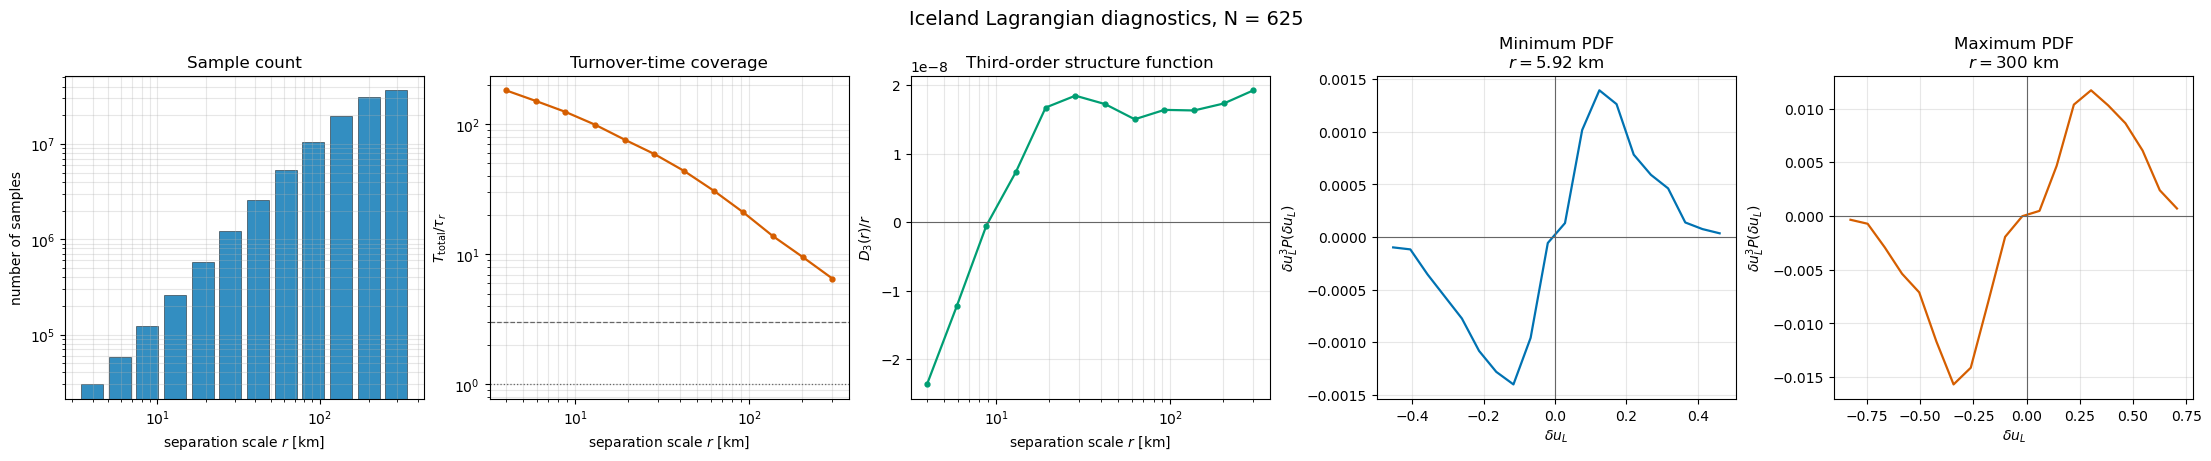

In [60]:
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 1. 读取结果
# ============================================================

result = result_289

r_km = np.asarray(
    result["dist_axis"],
    dtype=float,
).ravel()

r_m = r_km * 1000.0

SF2 = np.asarray(
    result["SF2"],
    dtype=float,
).ravel()

SF3 = np.asarray(
    result["SF3"],
    dtype=float,
).ravel()

nsample = np.asarray(
    result["nsample"],
    dtype=float,
).ravel()

dl_reservoir = np.asarray(
    result["dl_reservoir"],
    dtype=float,
)

dl_reservoir_count = np.asarray(
    result["dl_reservoir_count"],
    dtype=int,
).ravel()


# ============================================================
# 2. 统一长度
# ============================================================

nscale = min(
    r_km.size,
    SF2.size,
    SF3.size,
    nsample.size,
    dl_reservoir.shape[0],
    dl_reservoir_count.size,
)

r_km = r_km[:nscale]
r_m = r_m[:nscale]
SF2 = SF2[:nscale]
SF3 = SF3[:nscale]
nsample = nsample[:nscale]
dl_reservoir = dl_reservoir[:nscale]
dl_reservoir_count = dl_reservoir_count[:nscale]


# ============================================================
# 3. T_total / tau_r
# ============================================================

T_total = float(
    result["days"]
) * 86400.0

T_total_over_tau = np.divide(
    T_total * np.sqrt(
        np.maximum(SF2, 0.0)
    ),
    r_m,
    out=np.full(
        nscale,
        np.nan,
    ),
    where=(
        np.isfinite(r_m)
        & (r_m > 0)
        & np.isfinite(SF2)
        & (SF2 > 0)
    ),
)


# ============================================================
# 4. D3/r
# ============================================================

D3_over_r = np.divide(
    SF3,
    r_m,
    out=np.full(
        nscale,
        np.nan,
    ),
    where=(
        np.isfinite(r_m)
        & (r_m > 0)
        & np.isfinite(SF3)
    ),
)


# ============================================================
# 5. PDF helper
# ============================================================

def get_pdf_contribution(
    scale_index,
    nbins=20,
):

    count = int(
        dl_reservoir_count[scale_index]
    )

    count = max(
        0,
        min(
            count,
            dl_reservoir.shape[1],
        ),
    )

    sample = dl_reservoir[
        scale_index,
        :count,
    ]

    sample = sample[
        np.isfinite(sample)
    ]

    if sample.size == 0:
        return None

    xmin = np.nanmin(sample)
    xmax = np.nanmax(sample)

    if xmin == xmax:

        width = max(
            1.0,
            abs(xmin) * 0.1,
        )

        xmin -= width
        xmax += width

    bins = np.linspace(
        xmin,
        xmax,
        nbins + 1,
    )

    centers = 0.5 * (
        bins[:-1]
        + bins[1:]
    )

    pdf, _ = np.histogram(
        sample,
        bins=bins,
        density=True,
    )

    contribution = (
        centers**3 * pdf
    )

    return centers, contribution


minimum_scale_index = 1
maximum_scale_index = nscale - 1

pdf_min = get_pdf_contribution(
    minimum_scale_index,
)

pdf_max = get_pdf_contribution(
    maximum_scale_index,
)


# ============================================================
# 6. 创建 1 × 5 图
# ============================================================

fig, axes = plt.subplots(
    nrows=1,
    ncols=5,
    figsize=(22, 4.5),
    constrained_layout=True,
)


# ============================================================
# 第一列：nsample
# ============================================================

ax = axes[0]

valid = (
    np.isfinite(r_km)
    & (r_km > 0)
    & np.isfinite(nsample)
    & (nsample > 0)
)

rv = r_km[valid]
nv = nsample[valid]

if rv.size > 1:

    log_r = np.log10(rv)

    log_edges = np.empty(
        rv.size + 1
    )

    log_edges[1:-1] = 0.5 * (
        log_r[:-1]
        + log_r[1:]
    )

    log_edges[0] = (
        log_r[0]
        - 0.5 * (
            log_r[1]
            - log_r[0]
        )
    )

    log_edges[-1] = (
        log_r[-1]
        + 0.5 * (
            log_r[-1]
            - log_r[-2]
        )
    )

    edges = 10.0**log_edges

    ax.bar(
        rv,
        nv,
        width=0.78 * (
            edges[1:]
            - edges[:-1]
        ),
        color="#0072B2",
        alpha=0.8,
        edgecolor="black",
        linewidth=0.4,
    )

    ax.set_xscale("log")
    ax.set_yscale("log")

ax.set_xlabel(
    "separation scale $r$ [km]"
)

ax.set_ylabel(
    "number of samples"
)

ax.set_title(
    "Sample count"
)

ax.grid(
    True,
    which="both",
    alpha=0.3,
)


# ============================================================
# 第二列：T_total / tau_r
# ============================================================

ax = axes[1]

valid = (
    np.isfinite(r_km)
    & (r_km > 0)
    & np.isfinite(T_total_over_tau)
    & (T_total_over_tau > 0)
)

ax.loglog(
    r_km[valid],
    T_total_over_tau[valid],
    marker="o",
    markersize=3.5,
    color="#D55E00",
    linewidth=1.6,
)

ax.axhline(
    1.0,
    color="0.4",
    linestyle=":",
    linewidth=0.9,
)

ax.axhline(
    3.0,
    color="0.4",
    linestyle="--",
    linewidth=0.9,
)

ax.set_xlabel(
    "separation scale $r$ [km]"
)

ax.set_ylabel(
    r"$T_{\rm total}/\tau_r$"
)

ax.set_title(
    "Turnover-time coverage"
)

ax.grid(
    True,
    which="both",
    alpha=0.3,
)


# ============================================================
# 第三列：D3/r
# ============================================================

ax = axes[2]

valid = (
    np.isfinite(r_km)
    & (r_km > 0)
    & np.isfinite(D3_over_r)
)

ax.semilogx(
    r_km[valid],
    D3_over_r[valid],
    marker="o",
    markersize=3.5,
    color="#009E73",
    linewidth=1.6,
)

ax.axhline(
    0.0,
    color="0.4",
    linewidth=0.8,
)

ax.set_xlabel(
    "separation scale $r$ [km]"
)

ax.set_ylabel(
    r"$D_3(r)/r$"
)

ax.set_title(
    "Third-order structure function"
)

ax.grid(
    True,
    which="both",
    alpha=0.3,
)


# ============================================================
# 第四列：最小尺度 PDF
# ============================================================

ax = axes[3]

if pdf_min is not None:

    x_pdf, y_pdf = pdf_min

    ax.plot(
        x_pdf,
        y_pdf,
        color="#0072B2",
        linewidth=1.6,
    )

else:

    ax.text(
        0.5,
        0.5,
        "No PDF data",
        ha="center",
        va="center",
        transform=ax.transAxes,
    )

ax.axhline(
    0.0,
    color="0.4",
    linewidth=0.8,
)

ax.axvline(
    0.0,
    color="0.4",
    linewidth=0.8,
)

ax.set_xlabel(
    r"$\delta u_L$"
)

ax.set_ylabel(
    r"$\delta u_L^3P(\delta u_L)$"
)

ax.set_title(
    f"Minimum PDF\n"
    f"$r={r_km[minimum_scale_index]:.3g}$ km"
)

ax.grid(
    True,
    alpha=0.3,
)


# ============================================================
# 第五列：最大尺度 PDF
# ============================================================

ax = axes[4]

if pdf_max is not None:

    x_pdf, y_pdf = pdf_max

    ax.plot(
        x_pdf,
        y_pdf,
        color="#D55E00",
        linewidth=1.6,
    )

else:

    ax.text(
        0.5,
        0.5,
        "No PDF data",
        ha="center",
        va="center",
        transform=ax.transAxes,
    )

ax.axhline(
    0.0,
    color="0.4",
    linewidth=0.8,
)

ax.axvline(
    0.0,
    color="0.4",
    linewidth=0.8,
)

ax.set_xlabel(
    r"$\delta u_L$"
)

ax.set_ylabel(
    r"$\delta u_L^3P(\delta u_L)$"
)

ax.set_title(
    f"Maximum PDF\n"
    f"$r={r_km[maximum_scale_index]:.3g}$ km"
)

ax.grid(
    True,
    alpha=0.3,
)


# ============================================================
# 总标题
# ============================================================

fig.suptitle(
    "Iceland Lagrangian diagnostics, N = 625",
    fontsize=14,
)

output_png=f'/meddy/simingzhang/Data/SF_directly/recipe_Iceland_SM{ini}_625.png'
fig.savefig(output_png,
    dpi=500,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()